In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import PermutationLpModel, PermutationSwapLpModel

In [3]:
def verify_lp_winners(voter_positions, candidates, strategies, winners):
    """Check that voters generated by the LP actually elect the target winners."""
    lp_positions = voter_positions[
        ~np.isnan(voter_positions[:, 0])
    ]  # drop NaN rows (rankings not realizable in 2D)
    lp_voters = [Voter(position=p) for p in lp_positions]
    lp_result = Election(candidates=candidates, voters=lp_voters).compare_strategies(
        strategies=strategies
    )

    print(f"voters: {len(lp_voters)}\n")
    print(f"{'rule':<12} {'target':>7} {'actual':>7}  ok")
    all_ok = True
    for s in strategies:
        target_idx = winners[s.key]
        actual_idx = candidates.index(lp_result.winner(s))
        ok = target_idx == actual_idx
        all_ok &= ok
        print(f"{s.key:<12} {target_idx:>7} {actual_idx:>7}  {'OK' if ok else 'X'}")

    assert all_ok, "LP model does NOT reproduce the target winners!"
    print("\nAll winners match — LP model is correct.")

In [4]:
def sample_voters(
    candidates: list[Candidate],
    shares: list[float],
    total: int,
    sigma: float = 1.0,
    seed: int | None = None,
) -> list[Voter]:
    """
    Sample voters around candidate positions using a Gaussian distribution.

    Args:
        candidates: list of Candidate (each with a .position (x, y))
        shares:     percentage of voters per candidate, same length as candidates
                    (must sum to 100)
        total:      total number of voters to sample
        sigma:      std dev of Gaussian spread around each candidate
        seed:       optional random seed for reproducibility

    Returns:
        list of Voter
    """
    if len(shares) != len(candidates):
        raise ValueError("shares must have the same length as candidates")

    rng = np.random.default_rng(seed)
    voters = []

    for candidate, share in zip(candidates, shares):
        x, y = candidate.position
        n = round(total * share / 100)
        xs = rng.normal(loc=x, scale=sigma, size=n)
        ys = rng.normal(loc=y, scale=sigma, size=n)
        voters.extend(Voter(position=np.array([vx, vy])) for vx, vy in zip(xs, ys))

    return voters

In [5]:
positions = [(-5, -5), (2, -3), (1, 2), (-2, 7), (7, 6)]
shares = [8.6, 30.7, 14.4, 35.4, 7.2]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

N_VOTERS = 1000
N_CANDIDATES = len(candidates)

strategies = [PluralityStrategy(), BordaCountStrategy()]


Plurality rule  -> C3
Borda count     -> C2
Tie:  False


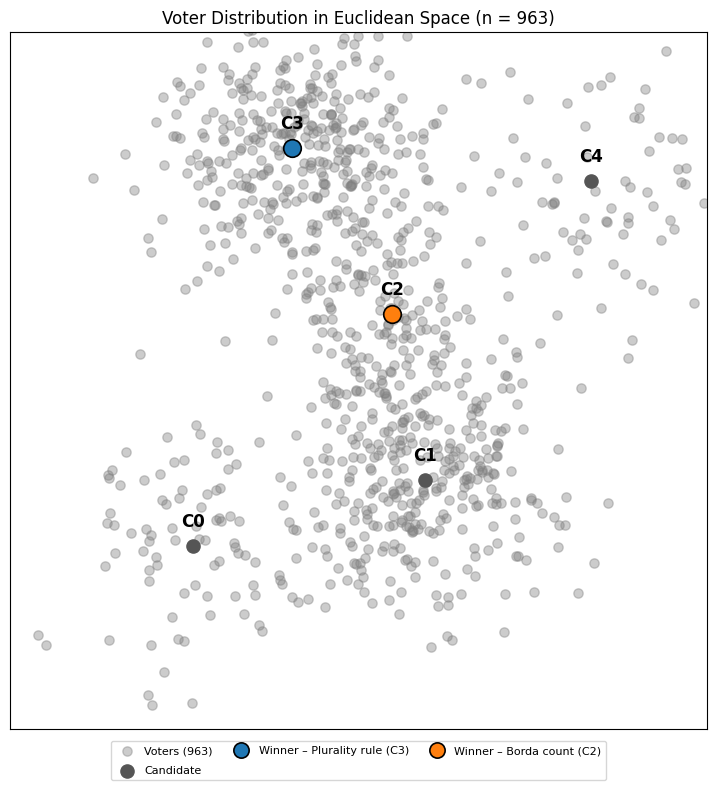

In [6]:
# Sample an initial electorate clustered around the candidates (per `shares`).
voters = sample_voters(candidates, shares, N_VOTERS, sigma=2.0, seed=0)

# Who wins with this initial electorate, before adding any voters?
initial_result = Election(candidates=candidates, voters=voters).compare_strategies(
    strategies
)

for s in strategies:
    print(f"{s.name:<15} -> C{candidates.index(initial_result.winner(s))}")

print("Tie: ", any(tally.is_tie() for tally in initial_result.tallies.values()))

plot_results(initial_result)

In [7]:
winners = {
    PluralityStrategy().key: 3,
    BordaCountStrategy().key: 1,
}

In [8]:
def run_swap(objective="minmax", mode="fixed", n_add=N_VOTERS):
    """Add voters to the fixed `voters` electorate so the target `winners` win.

    objective : how to spread the added voters (only used when mode="fixed")
    mode       : "fixed"   -> add exactly n_add voters
                 "minimal" -> add as few voters as possible
    """
    model = PermutationSwapLpModel(
        candidates=candidates,
        voters=voters,
        n_voters=n_add,
        winners=winners,
        objective=objective,
        mode=mode,
    )
    status = model.solve()
    print(f"mode={mode}, objective={objective} -> {status}")
    assert status == "Optimal"

    existing = np.array([v.position for v in voters])
    added = model.generate_voter_positions()
    print(f"existing: {len(existing)}, added: {len(added)}\n")

    plot_lp_swap_result(candidates, existing, added, winners)

    # Verify on the combined electorate (existing + added).
    combined = np.vstack([existing, added]) if len(added) else existing
    verify_lp_winners(combined, candidates, strategies, winners)
    return model

mode=fixed, objective=minmax -> Optimal
existing: 963, added: 888



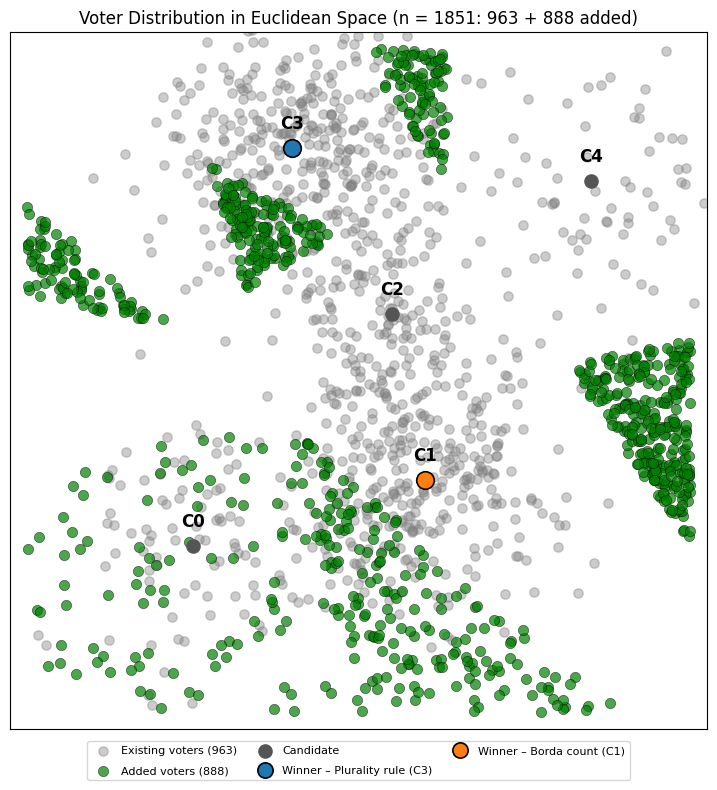

voters: 1851

rule          target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match — LP model is correct.


In [9]:
# fixed mode, "minmax" objective: add exactly N_VOTERS, spread as evenly as possible.
_ = run_swap(objective="minmax", mode="fixed")

mode=fixed, objective=maxmin -> Optimal
existing: 963, added: 1000



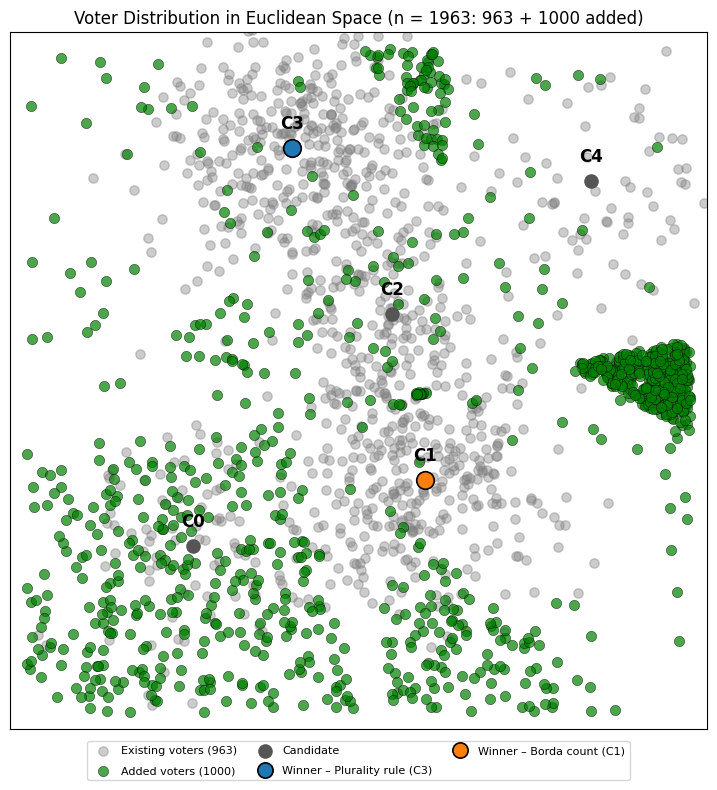

voters: 1963

rule          target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match — LP model is correct.


In [10]:
# fixed mode, "maxmin" objective: lift the smallest bucket.
_ = run_swap(objective="maxmin", mode="fixed")

mode=fixed, objective=range -> Optimal
existing: 963, added: 888



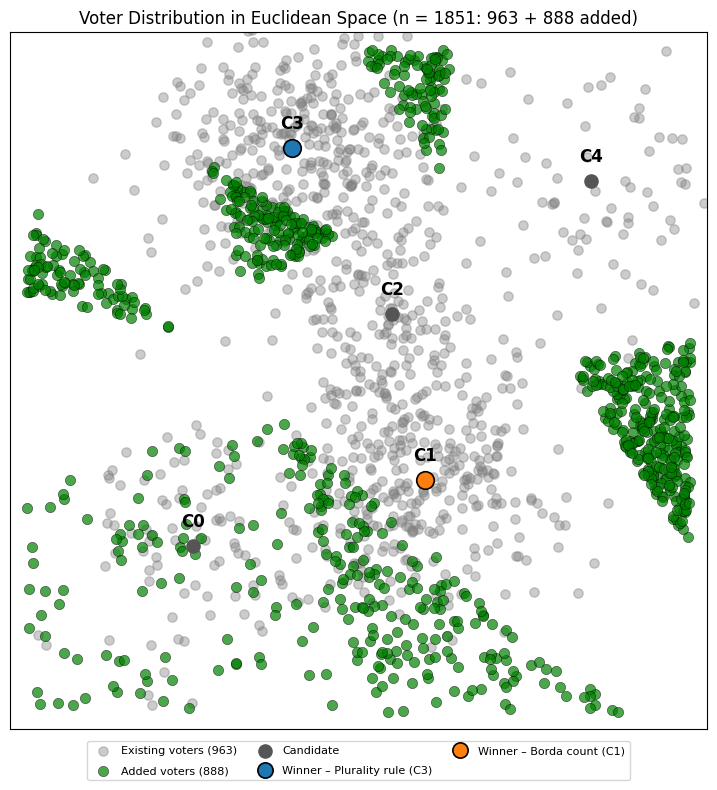

voters: 1851

rule          target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match — LP model is correct.


In [11]:
# fixed mode, "range" objective: squeeze the spread (max - min bucket).
_ = run_swap(objective="range", mode="fixed")

mode=minimal, objective=minmax -> Optimal
existing: 963, added: 569



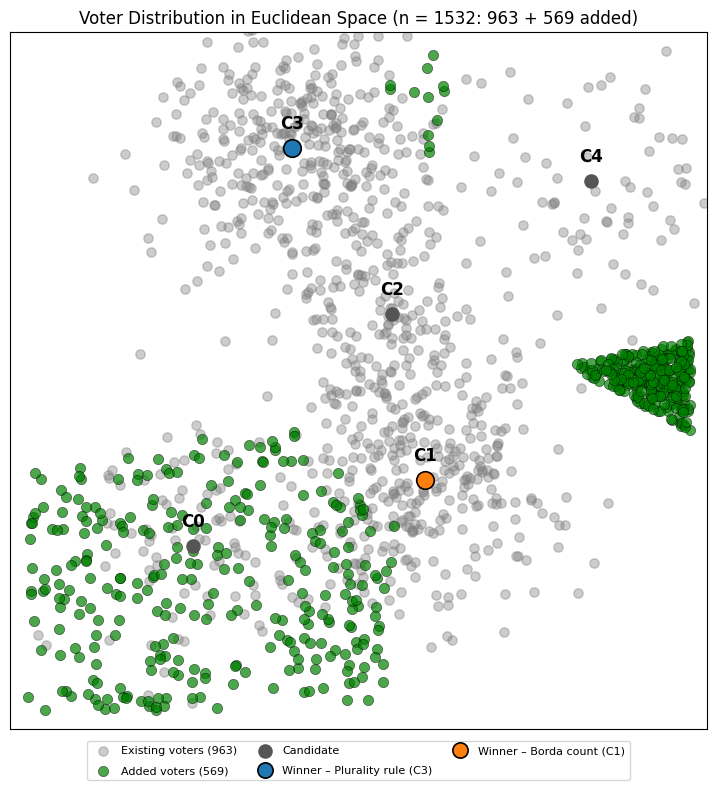

voters: 1532

rule          target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match — LP model is correct.


In [12]:
# minimal mode: add as few voters as possible (objective is ignored).
# The added voters tend to be concentrated in a few regions.
_ = run_swap(mode="minimal")

# Search: which outcomes can be reached by adding voters?

Starting from the natural outcome of the sampled electorate, enumerate every winner
assignment (full triple, and each pair of strategies) and find those that a swap of
**added** voters can produce — together with the minimum number of voters needed.
Combinations that no set of 2D-realizable rankings can produce come back `Infeasible`
and are skipped.

In [13]:
from itertools import product, combinations

# One reused model: the sampling pool depends only on candidates + voters (not on the
# target winners), so caching it once keeps the whole scan fast. We only change
# `.winners` and rebuild the (cheap) constraints for each candidate target.
_search_model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    n_voters=0,
    winners={},
    mode="minimal",  # minimize the number of voters we have to add
    pool_size=100_000,
)
_search_model._sample_pool()  # build & cache the pool a single time


def natural_winners(strategies_subset) -> tuple[int, ...]:
    """Winners of the current `voters` electorate, as candidate indices."""
    result = Election(candidates=candidates, voters=voters).compare_strategies(
        strategies_subset
    )
    return tuple(candidates.index(result.winner(s)) for s in strategies_subset)


def reachable_outcomes(strategies_subset):
    """Scan every winner-combination (other than the natural one).

    Returns (natural, reachable, unreachable) where:
      reachable   : list of (combo, added) sorted by how few voters it takes
      unreachable : list of combos no set of realizable rankings can produce
    """
    keys = [s.key for s in strategies_subset]
    base = natural_winners(strategies_subset)

    reachable, unreachable = [], []
    for combo in product(range(N_CANDIDATES), repeat=len(keys)):
        if combo == base:
            continue
        _search_model.winners = dict(zip(keys, combo))
        _search_model.build()  # reuses the cached pool
        if _search_model.solve() != "Optimal":
            unreachable.append(combo)  # no realizable way to produce this combo
            continue
        added = round(sum(v.varValue or 0 for v in _search_model.variables.values()))
        reachable.append((combo, int(added)))

    reachable.sort(key=lambda r: r[1])
    return base, reachable, unreachable

In [14]:
# Scan the full triple of strategies, then every pair.
subsets = [tuple(strategies)] + list(combinations(strategies, 2))

for subset in subsets:
    names = " + ".join(s.name for s in subset)
    base, reachable, unreachable = reachable_outcomes(list(subset))
    keys = tuple(s.key for s in subset)
    total = len(reachable) + len(unreachable)

    print(f"=== {names} ===")
    print(f"strategies: {keys}")
    print(f"natural outcome: {base}")

    print(f"reachable ({len(reachable)}):")
    for combo, added in reachable:
        print(f"  -> {combo}: add {added} voters")

    print(f"NOT reachable ({len(unreachable)}):")
    for combo in unreachable:
        print(f"  -> {combo}")

    print(f"summary: {len(reachable)}/{total} reachable, {len(unreachable)}/{total} not\n")

=== Plurality rule + Borda count ===
strategies: ('plurality', 'borda')
natural outcome: (3, 2)
reachable (24):
  -> (1, 2): add 44 voters
  -> (2, 2): add 133 voters
  -> (0, 2): add 231 voters
  -> (4, 2): add 253 voters
  -> (1, 1): add 300 voters
  -> (3, 3): add 438 voters
  -> (0, 1): add 462 voters
  -> (4, 1): add 470 voters
  -> (3, 1): add 569 voters
  -> (0, 3): add 661 voters
  -> (4, 3): add 668 voters
  -> (4, 4): add 816 voters
  -> (2, 1): add 877 voters
  -> (0, 0): add 889 voters
  -> (3, 4): add 1005 voters
  -> (1, 4): add 1019 voters
  -> (1, 3): add 1109 voters
  -> (3, 0): add 1109 voters
  -> (1, 0): add 1124 voters
  -> (2, 3): add 1317 voters
  -> (2, 4): add 2052 voters
  -> (2, 0): add 2284 voters
  -> (0, 4): add 3621 voters
  -> (4, 0): add 4089 voters
NOT reachable (0):
summary: 24/24 reachable, 0/24 not

=== Plurality rule + Borda count ===
strategies: ('plurality', 'borda')
natural outcome: (3, 2)
reachable (24):
  -> (1, 2): add 44 voters
  -> (2, 2): 

In [15]:
def run_swap_target(target, strategies_subset=None, mode="minimal", objective="minmax"):
    """Like run_swap, but for an explicit target instead of the global `winners`.

    target            : winners dict {key: cand_idx}, or a combo tuple aligned with
                        `strategies_subset` (e.g. a row from the reachability scan).
    strategies_subset : strategies the target refers to (defaults to `strategies`);
                        only needed to interpret a combo tuple and to verify.
    mode / objective  : passed through to PermutationSwapLpModel.
    """
    subset = strategies_subset if strategies_subset is not None else strategies
    if isinstance(target, dict):
        target_winners = target
    else:
        target_winners = {s.key: idx for s, idx in zip(subset, target)}

    model = PermutationSwapLpModel(
        candidates=candidates,
        voters=voters,
        n_voters=N_VOTERS,
        winners=target_winners,
        objective=objective,
        mode=mode,
    )
    status = model.solve()
    print(f"target={target_winners}, mode={mode}, objective={objective} -> {status}")
    assert status == "Optimal"

    existing = np.array([v.position for v in voters])
    added = model.generate_voter_positions()
    print(f"existing: {len(existing)}, added: {len(added)}\n")

    plot_lp_swap_result(candidates, existing, added, target_winners)

    combined = np.vstack([existing, added]) if len(added) else existing
    verify_lp_winners(combined, candidates, subset, target_winners)
    return model

cheapest flip: (1, 2) (needs 44 added voters)

target={'plurality': 1, 'borda': 2}, mode=minimal, objective=minmax -> Optimal
existing: 963, added: 44



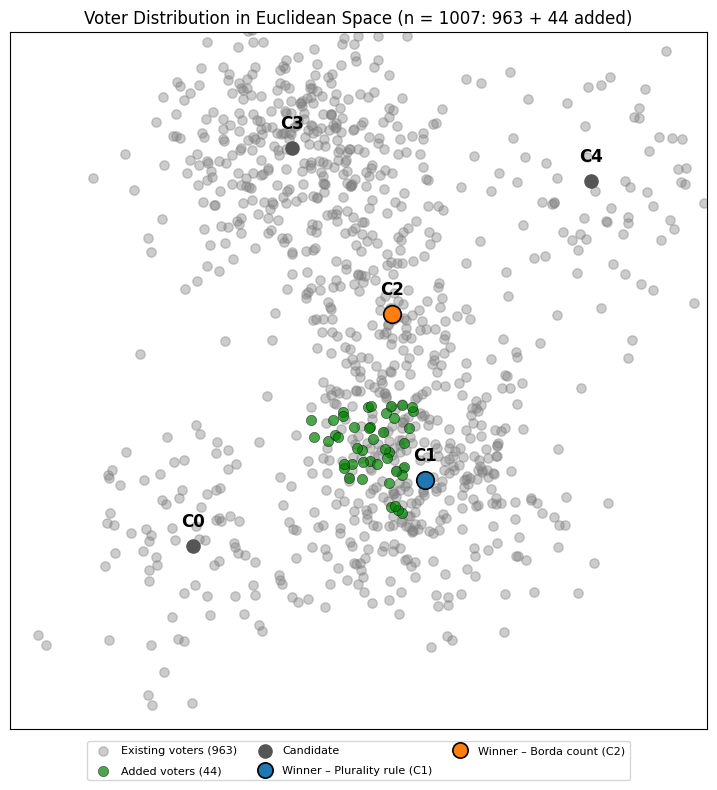

voters: 1007

rule          target  actual  ok
plurality          1       1  OK
borda              2       2  OK

All winners match — LP model is correct.


In [16]:
# Draw an example: the cheapest reachable flip of the full strategy triple.
_, reachable, _ = reachable_outcomes(list(strategies))
target_combo, n_added = reachable[0]
print(f"cheapest flip: {target_combo} (needs {n_added} added voters)\n")

# "minimal" matches the search (fewest voters); try mode="fixed" to spread them out.
_ = run_swap_target(target_combo, strategies, mode="minimal")

In [17]:
_cand_pos = np.array([c.position for c in candidates], dtype=float)


def winner_spread(combo, kind="mean"):
    """How far apart the *distinct* winning candidates are.

    kind="mean" -> mean pairwise distance (general spread)
    kind="min"  -> smallest pairwise distance (forces ALL winners far apart)
    Returns 0 if every strategy picks the same candidate.
    """
    idxs = sorted(set(combo))
    if len(idxs) < 2:
        return 0.0
    dists = [
        np.linalg.norm(_cand_pos[i] - _cand_pos[j])
        for i, j in combinations(idxs, 2)
    ]
    return float(np.mean(dists) if kind == "mean" else np.min(dists))

natural outcome (3, 2): spread = 5.83

most-dispersed reachable outcomes (* = more spread than natural):
  (0, 4): spread=16.28, add 3621 voters *
  (4, 0): spread=16.28, add 4089 voters *
  (0, 3): spread=12.37, add 661 voters *
  (3, 0): spread=12.37, add 1109 voters *
  (3, 1): spread=10.77, add 569 voters *
  (1, 3): spread=10.77, add 1109 voters *
  (4, 1): spread=10.30, add 470 voters *
  (1, 4): spread=10.30, add 1019 voters *
  (0, 2): spread=9.22, add 231 voters *
  (2, 0): spread=9.22, add 2284 voters *

target={'plurality': 0, 'borda': 4}, mode=minimal, objective=minmax -> Optimal
existing: 963, added: 3621



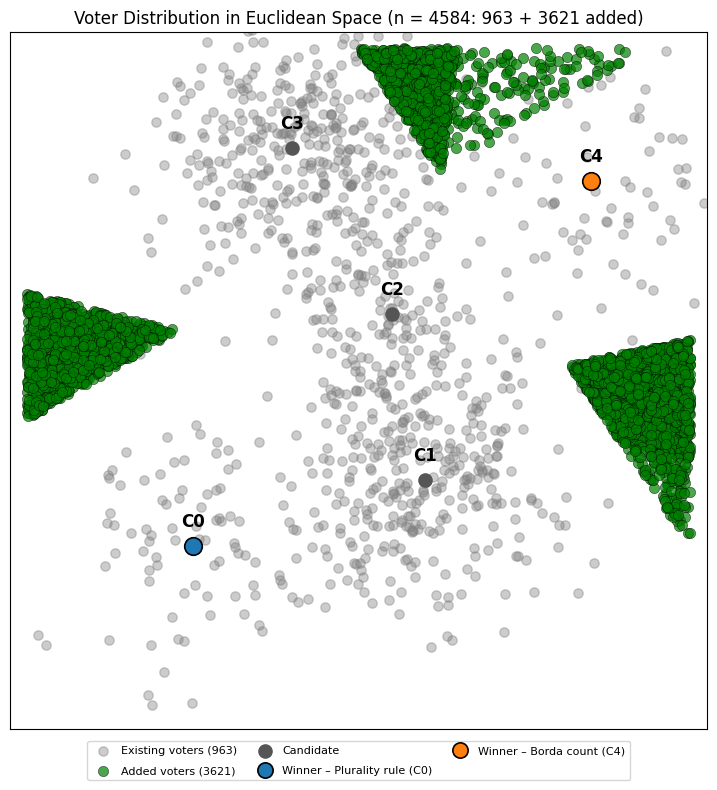

voters: 4584

rule          target  actual  ok
plurality          0       0  OK
borda              4       4  OK

All winners match — LP model is correct.


In [18]:
# Rank reachable outcomes by how spread-out their winners are, vs. the natural one.
base, reachable, _ = reachable_outcomes(list(strategies))
base_spread = winner_spread(base)
print(f"natural outcome {base}: spread = {base_spread:.2f}\n")

# Prefer the most dispersed; break ties by fewest added voters.
ranked = sorted(reachable, key=lambda r: (-winner_spread(r[0]), r[1]))
print("most-dispersed reachable outcomes (* = more spread than natural):")
for combo, added in ranked[:10]:
    sp = winner_spread(combo)
    flag = " *" if sp > base_spread else ""
    print(f"  {combo}: spread={sp:.2f}, add {added} voters{flag}")

# Draw the most spread-out reachable outcome.
best_combo, _ = ranked[0]
print()
_ = run_swap_target(best_combo, strategies, mode="minimal")

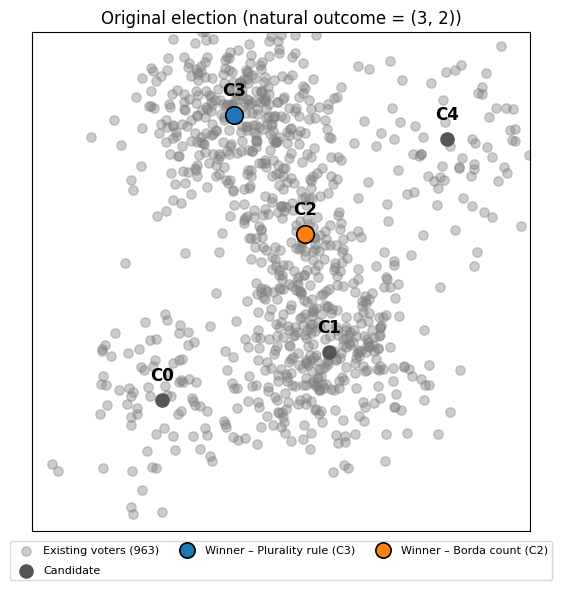

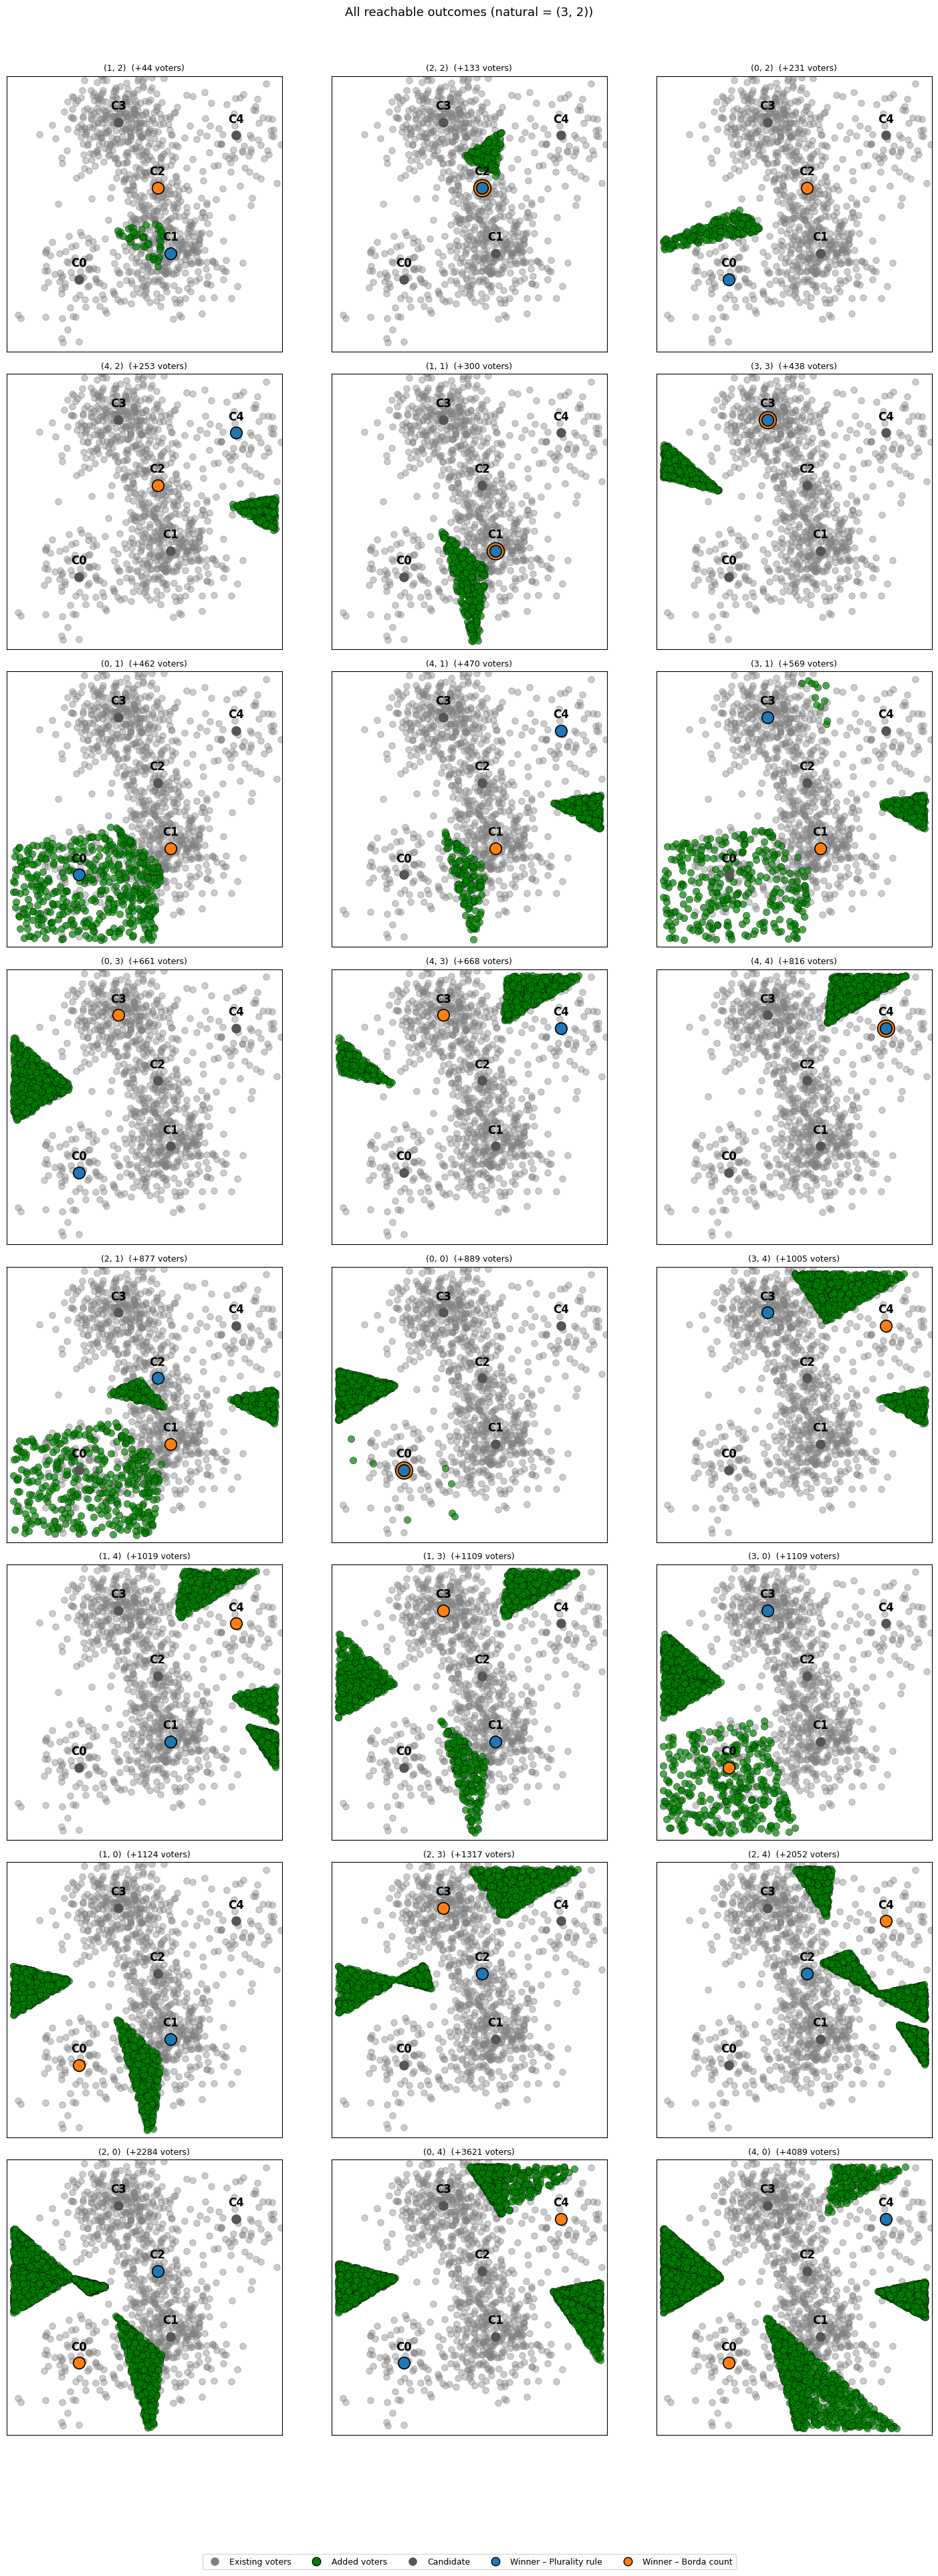

In [19]:
from matplotlib.lines import Line2D

# Reuses `base` and `reachable` from the cell above.
existing = np.array([v.position for v in voters])
no_added = np.empty((0, 2))

# --- original (natural) election result, shown on top ---
natural_winners_d = {s.key: idx for s, idx in zip(strategies, base)}
fig0, ax0 = plt.subplots(figsize=(7, 6))
plot_lp_swap_result(candidates, existing, no_added, natural_winners_d, ax=ax0)
ax0.set_title(f"Original election (natural outcome = {base})")
fig0.tight_layout()
plt.show()

# --- every reachable change, no per-panel legends ---
ncols = 3
nrows = (len(reachable) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.8))
axes = np.atleast_1d(axes).ravel()

for ax, (combo, added_count) in zip(axes, reachable):
    target = {s.key: idx for s, idx in zip(strategies, combo)}
    _search_model.winners = target
    _search_model.build()
    _search_model.solve()
    added = _search_model.generate_voter_positions()
    plot_lp_swap_result(candidates, existing, added, target, ax=ax, legend=False)
    ax.set_title(f"{combo}  (+{added_count} voters)", fontsize=9)

# Hide any leftover empty subplots.
for ax in axes[len(reachable):]:
    ax.axis("off")

# One shared legend for the whole grid.
palette = plt.cm.tab10.colors


def legend_dot(color, label, edge="black"):
    return Line2D(
        [], [], marker="o", linestyle="None", markerfacecolor=color,
        markeredgecolor=edge, markersize=9, label=label,
    )


shared = [
    legend_dot("gray", "Existing voters", edge="none"),
    legend_dot("green", "Added voters"),
    legend_dot("#555555", "Candidate", edge="none"),
]
for i, s in enumerate(strategies):
    shared.append(legend_dot(palette[i % len(palette)], f"Winner – {s.name}"))

fig.suptitle(f"All reachable outcomes (natural = {base})", fontsize=13)
fig.legend(
    handles=shared, loc="lower center", ncols=len(shared),
    fontsize=9, bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()